# Hurricane Helene (2024) — AI Model Track Comparison

Compare tropical cyclone tracks from **GraphCast**, **FCN3**, and **AIFS**
against ERA5 reanalysis for Hurricane Helene, at three lead times before
landfall (T−72 h, T−168 h, T−240 h).

**Verification target:** Helene's Florida Big Bend landfall,
snapped to `2024-09-27 00:00 UTC`.

| Lead | Init time (UTC)  | Steps (6 h) |
|------|------------------|-------------|
| 72 h | 2024-09-24 00:00 | 12          |
| 168 h| 2024-09-20 00:00 | 28          |
| 240 h| 2024-09-17 00:00 | 40          |

In [1]:
import os

# Must be set BEFORE importing torch.
os.environ["FORCE_CUDA_EXTENSION"] = "1"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9"
os.environ["CUDA_HOME"] = "/usr/local/cuda"
os.environ["EARTH2STUDIO_CACHE"] = os.path.expanduser("~/.cache/earth2studio")
os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"
# Prevent JAX from pre-allocating all GPU memory (needed for GraphCast + PyTorch coexistence).
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm

from earth2studio.models.px import FCN3, AIFS, GraphCastOperational
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import WB2ERA5, ARCO, IFS, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("DONE")

/home/jovyan/hurricane-forecasts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


 parsing error, invalid json config /dev/null
 failed to load user config: /dev/null Invalid argument
 cuFile configuration load error
 cuFile initialization failed
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


Device: cuda
GPU   : NVIDIA L40
VRAM  : 47.7 GB
DONE


In [3]:
#storm config
STORM_NAME = "Helene"

VERIFICATION_TIME = datetime(2024, 9, 27, 0)

LEAD_TIMES_H = [72, 168, 240]

# Derived: init time and step count for each lead.
INIT_TIMES = {h: VERIFICATION_TIME - timedelta(hours=h) for h in LEAD_TIMES_H}
N_STEPS    = {h: h // 6 for h in LEAD_TIMES_H}

OUT_DIR = Path("./outputs/helene")
OUT_DIR.mkdir(parents=True, exist_ok=True)


PLOT_EXTENT = (-100, -65, 15, 40)

LANDFALL_LAT = 30.0
LANDFALL_LON = -83.7

MODEL_COLORS = {
    "FCN3":      "#ff7f0e",  # orange
    "AIFS":      "#2ca02c",  # green
    "GraphCast": "#1f77b4",  # blue
    "ERA5":      "#000000",  # black
}

# Print the resolved init times.
for h in LEAD_TIMES_H:
    print(f"  T-{h:>3}h : init={INIT_TIMES[h]}  steps={N_STEPS[h]}")

  T- 72h : init=2024-09-24 00:00:00  steps=12
  T-168h : init=2024-09-20 00:00:00  steps=28
  T-240h : init=2024-09-17 00:00:00  steps=40


In [4]:
def run_tc_inference(prognostic, data_source, start_time, nsteps, save_path):
    """Run a prognostic model through TCTrackerWuDuan and save tracks.

    Args:
        prognostic:   Loaded Earth2Studio prognostic model.
        data_source:  Data source for initial conditions (e.g. WB2ERA5).
        start_time:   datetime — forecast initialization time.
        nsteps:       Number of 6h autoregressive steps.
        save_path:    Path to save the output .pt track tensor.

    Returns:
        torch.Tensor of shape (batch, num_paths, time_steps, 2).
    """
    # Skip if already cached — avoids re-running expensive inference.
    if Path(save_path).exists():
        print(f"  cached → {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    # Move model to GPU.
    prognostic = prognostic.to(DEVICE)

    # Fresh tracker instance per run — reset_path_buffer clears any
    # leftover state from a previous call.
    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    # Fetch initial condition from the data source.
    # fetch_data returns (tensor, coords_dict) on the target device.
    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    # Align coords to the model's expected layout.
    x, coords = map_coords(x, coords, prognostic.input_coords())

    # Step through the autoregressive iterator.
    # Each iteration: model produces next state → tracker ingests it.
    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        # map_coords aligns the model output to tracker's expected vars.
        x, coords = map_coords(x, coords, tracker.input_coords())
        # Tracker call: updates internal path buffer, returns current tracks.
        output, _ = tracker(x, coords)
        output = output[:, 0]  # take the first (and usually only) batch dim
        if step == nsteps:
            break

    # Save tracks as a .pt tensor for fast reload.
    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  → {save_path}")
    return tracks

In [5]:
def run_era5_truth(data_source, start_time, nsteps, save_path):
    """Track ERA5 reanalysis with TCTrackerWuDuan over the same time window as a forecast."""
    if Path(save_path).exists():
        print(f"  cached → {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    times = [start_time + timedelta(hours=6 * i) for i in range(nsteps + 1)]
    for step, time in tqdm(enumerate(times), total=len(times)):
        try:
            da = data_source(time, tracker.input_coords()["variable"])
        except RuntimeError:
            # Corrupted cache chunk — retry with a fresh uncached download.
            from earth2studio.data import ARCO
            da = ARCO(cache=False)(time, tracker.input_coords()["variable"])
        x, coords = prep_data_array(da, device=DEVICE)
        output, _ = tracker(x, coords)

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  → {save_path}")
    return tracks

In [6]:
# ARCO = Analysis-Ready, Cloud Optimized ERA5 on GCS.
# Used for both model initialization and ERA5 truth tracking.
# WB2ERA5 has a hard cutoff of 2023-01-11 — all Helene init times are in Sep 2024.
data_source = ARCO(cache=True)

In [7]:
from earth2studio.data import CDS

# Replace your current ifs_data_source with this:
aifs_data_source = CDS(cache=True)

## AIFS forecasts

AIFS (ECMWF) — GNN encoder + sliding-window transformer processor.
First ML model fully operational at a major NWP center (Feb 2025).

In [8]:
%%time
aifs = AIFS.load_model(AIFS.load_default_package())

CPU times: user 5.45 s, sys: 648 ms, total: 6.09 s
Wall time: 6.05 s


In [9]:
%%time
aifs_tracks_72 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "aifs_72h.pt",
)

  cached → outputs/helene/aifs_72h.pt
CPU times: user 1.63 ms, sys: 45 μs, total: 1.67 ms
Wall time: 1.91 ms


In [10]:
%%time
aifs_tracks_168 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "aifs_168h.pt",
)

  cached → outputs/helene/aifs_168h.pt
CPU times: user 862 μs, sys: 0 ns, total: 862 μs
Wall time: 718 μs


In [11]:
%%time
aifs_tracks_240 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "aifs_240h.pt",
)

  cached → outputs/helene/aifs_240h.pt
CPU times: user 681 μs, sys: 49 μs, total: 730 μs
Wall time: 600 μs


In [12]:
import gc
del aifs
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved


## GraphCast forecasts

GraphCast (Google DeepMind) — autoregressive GNN on an icosahedral multi-mesh.
Uses JAX under the hood; `XLA_PYTHON_CLIENT_PREALLOCATE=false` prevents it from
grabbing all GPU memory before PyTorch can use it.

In [13]:
%%time
graphcast = GraphCastOperational.load_model(GraphCastOperational.load_default_package())

CPU times: user 371 ms, sys: 757 ms, total: 1.13 s
Wall time: 20.1 s


In [14]:
%%time
gc_tracks_72 = run_tc_inference(
    graphcast, data_source,
    INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "graphcast_72h.pt",
)

2026-05-19 20:08:29.029 | DEBUG    | earth2studio.data.arco:_async_init:125 - Using Multi-Storage Client for ARCO data access


Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:  10%|████████                                                                        | 1/10 [00:00<00:03,  2.84it/s]

Fetching ARCO data:  50%|████████████████████████████████████████                                        | 5/10 [00:00<00:00,  7.10it/s]

Fetching ARCO data:  60%|████████████████████████████████████████████████                                | 6/10 [00:01<00:00,  5.08it/s]

...

 77%|████████████████████████████████████████████████████████████████████████████▏                      | 10/13 [01:38<00:08,  2.80s/it]

 85%|███████████████████████████████████████████████████████████████████████████████████▊               | 11/13 [01:39<00:04,  2.35s/it]

 92%|███████████████████████████████████████████████████████████████████████████████████████████▍       | 12/13 [01:40<00:02,  2.04s/it]

 92%|███████████████████████████████████████████████████████████████████████████████████████████▍       | 12/13 [01:42<00:08,  8.51s/it]

  saved  → outputs/helene/graphcast_72h.pt
CPU times: user 1min 40s, sys: 18.4 s, total: 1min 59s
Wall time: 1min 47s


In [15]:
%%time
gc_tracks_168 = run_tc_inference(
    graphcast, data_source,
    INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "graphcast_168h.pt",
)

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

...

 90%|████████████████████████████████████████████████████████████████████████████████████████▊          | 26/29 [00:36<00:03,  1.32s/it]

 93%|████████████████████████████████████████████████████████████████████████████████████████████▏      | 27/29 [00:37<00:02,  1.33s/it]

 97%|███████████████████████████████████████████████████████████████████████████████████████████████▌   | 28/29 [00:39<00:01,  1.33s/it]

 97%|███████████████████████████████████████████████████████████████████████████████████████████████▌   | 28/29 [00:40<00:01,  1.45s/it]

  saved  → outputs/helene/graphcast_168h.pt
CPU times: user 16.9 s, sys: 21.7 s, total: 38.6 s
Wall time: 50.3 s


In [16]:
%%time
gc_tracks_240 = run_tc_inference(
    graphcast, data_source,
    INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "graphcast_240h.pt",
)

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

...

 93%|███████████████████████████████████████████████████████████████████████████████████████████▊       | 38/41 [00:52<00:03,  1.32s/it]

 95%|██████████████████████████████████████████████████████████████████████████████████████████████▏    | 39/41 [00:54<00:02,  1.32s/it]

 98%|████████████████████████████████████████████████████████████████████████████████████████████████▌  | 40/41 [00:55<00:01,  1.32s/it]

 98%|████████████████████████████████████████████████████████████████████████████████████████████████▌  | 40/41 [00:56<00:01,  1.42s/it]

  saved  → outputs/helene/graphcast_240h.pt
CPU times: user 22.8 s, sys: 27.9 s, total: 50.7 s
Wall time: 1min 13s


In [17]:
del graphcast
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved


## ERA5 truth tracks

Run the same `TCTrackerWuDuan` on ERA5 reanalysis for each lead-time
window. This ensures truth and forecasts use an identical tracking
algorithm — no confound from different tracker implementations.

In [18]:
%%time
# One truth track per lead time. Each covers [init_time, verification_time].
era5_tracks_72 = run_era5_truth(
    data_source, INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "era5_72h.pt",
)

  0%|                                                                                                            | 0/13 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                         | 0/5 [00:00<?, ?it/s]

Fetching ARCO data:  20%|████████████████▏                                                                | 1/5 [00:00<00:00,  7.94it/s]

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00, 10.01it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 11.91it/s]

...

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.43it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.62it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:48<00:00,  3.25s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:48<00:00,  3.74s/it]

  saved  → outputs/helene/era5_72h.pt
CPU times: user 6.76 s, sys: 9.85 s, total: 16.6 s
Wall time: 48.6 s


In [19]:
%%time
era5_tracks_168 = run_era5_truth(
    data_source, INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "era5_168h.pt",
)

  0%|                                                                                                            | 0/29 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                         | 0/5 [00:00<?, ?it/s]

Fetching ARCO data:  20%|████████████████▏                                                                | 1/5 [00:00<00:00,  8.48it/s]

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00,  9.82it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 11.79it/s]

...

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00, 10.21it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 12.16it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [01:16<00:00,  1.71it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [01:16<00:00,  2.65s/it]

  saved  → outputs/helene/era5_168h.pt
CPU times: user 11.6 s, sys: 17.2 s, total: 28.8 s
Wall time: 1min 16s


In [20]:
%%time
era5_tracks_240 = run_era5_truth(
    data_source, INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "era5_240h.pt",
)

  0%|                                                                                                            | 0/41 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                         | 0/5 [00:00<?, ?it/s]

Fetching ARCO data:  20%|████████████████▏                                                                | 1/5 [00:00<00:00,  7.83it/s]

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00, 10.17it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 12.08it/s]

...

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00, 10.21it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 12.11it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [01:16<00:00,  1.80it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [01:16<00:00,  1.86s/it]

  saved  → outputs/helene/era5_240h.pt
CPU times: user 14.2 s, sys: 20 s, total: 34.1 s
Wall time: 1min 16s


## Load saved tracks
Reload-safe: works whether you just ran inference or restarted the kernel.

In [21]:
# Reload all .pt files — safe to re-run after a kernel restart.
aifs_tracks_72  = torch.load(OUT_DIR / "aifs_72h.pt",  map_location="cpu")
aifs_tracks_168 = torch.load(OUT_DIR / "aifs_168h.pt", map_location="cpu")
aifs_tracks_240 = torch.load(OUT_DIR / "aifs_240h.pt", map_location="cpu")

era5_tracks_72  = torch.load(OUT_DIR / "era5_72h.pt",  map_location="cpu")
era5_tracks_168 = torch.load(OUT_DIR / "era5_168h.pt", map_location="cpu")
era5_tracks_240 = torch.load(OUT_DIR / "era5_240h.pt", map_location="cpu")

gc_tracks_72  = torch.load(OUT_DIR / "graphcast_72h.pt",  map_location="cpu")
gc_tracks_168 = torch.load(OUT_DIR / "graphcast_168h.pt", map_location="cpu")
gc_tracks_240 = torch.load(OUT_DIR / "graphcast_240h.pt", map_location="cpu")

print(f"AIFS  T-72h : {aifs_tracks_72.shape}")
print(f"ERA5  T-72h : {era5_tracks_72.shape}")
print(f"GCast T-72h : {gc_tracks_72.shape}")

AIFS  T-72h : torch.Size([1, 16, 13, 4])
ERA5  T-72h : torch.Size([1, 17, 13, 4])
GCast T-72h : torch.Size([1, 16, 13, 4])


## Plot 1 — Track comparison maps

In [22]:
def plot_tracks(models_list, extent, title, init_time, nsteps, save_path=None):
    """Plot TC tracks with 6-hourly markers on a Cartopy map.

    Track tensor variable order: [tc_lat, tc_lon (0-360), tc_msl (Pa), tc_w10m (m/s)].
    Marker size scales with 10-m wind speed to indicate intensity evolution.

    Args:
        models_list:  List of dicts with keys: name (str), tracks (Tensor), color (str).
                      ERA5 is drawn with a solid line; forecast models with dashed.
        extent:       (lon_min, lon_max, lat_min, lat_max).
        title:        Plot title string.
        init_time:    datetime of forecast initialization.
        nsteps:       Number of 6-h steps (used for axis annotation only).
        save_path:    Optional path to save the figure.
    """
    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(11, 7),
    )

    # --- geographic features ---
    ax.add_feature(cfeature.LAND, facecolor="#e8e8e8", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="#d0e8f5", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="0.3", zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.3, linestyle=":", edgecolor="0.5", zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="0.4", zorder=3)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    for m in models_list:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        ls = "-"  if m["name"].startswith("ERA5") else "--"
        lw = 2.2  if m["name"].startswith("ERA5") else 1.8
        label_used = False

        # tracks: (batch, num_paths, time_steps, 4) → [tc_lat, tc_lon, tc_msl, tc_w10m]
        for p in range(tracks.shape[1]):
            lats = tracks[0, p, :, 0]
            lons = tracks[0, p, :, 1] - 360.0   # 0-360 → negative; PlateCarree handles it
            w10m = tracks[0, p, :, 3]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() < 2:
                continue

            idx = np.where(mask)[0]
            lv, lnv, wv = lats[idx], lons[idx], w10m[idx]

            # Only the first valid path carries the legend label.
            ax.plot(
                lnv, lv, color=m["color"], linewidth=lw, linestyle=ls,
                label=m["name"] if not label_used else "",
                transform=ccrs.PlateCarree(), zorder=5,
            )
            label_used = True

            # Markers sized by 10-m wind (intensity proxy); area ∝ wind speed.
            sizes = np.clip(wv * 3.5, 15, 160)
            ax.scatter(
                lnv, lv, s=sizes, color=m["color"],
                edgecolors="white", linewidths=0.5,
                transform=ccrs.PlateCarree(), zorder=6,
            )

            # Open ring at init and final (verification) steps.
            for i, sz in [(0, 70), (-1, 90)]:
                ax.scatter(
                    lnv[i], lv[i], s=sz,
                    facecolors="none", edgecolors=m["color"], linewidths=1.6,
                    transform=ccrs.PlateCarree(), zorder=7,
                )

    # --- landfall marker ---
    ax.plot(
        LANDFALL_LON, LANDFALL_LAT,
        marker="*", color="#d62728", markersize=16,
        markeredgecolor="white", markeredgewidth=0.8,
        linestyle="None", label="Observed landfall",
        transform=ccrs.PlateCarree(), zorder=10,
    )

    # --- gridlines ---
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--",
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    # --- legend + annotations ---
    ax.legend(loc="lower right", fontsize=9, framealpha=0.9, edgecolor="0.7", handlelength=2.5)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
   
    fig.tight_layout()
    if save_path:
        fig.savefig(str(save_path), dpi=150, bbox_inches="tight")
        print(f"saved → {save_path}")
    plt.show()

In [23]:
import pandas as pd

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km. Inputs in degrees, broadcasts with numpy."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def select_helene_path(track_tensor):
    """Pick the path whose final position is closest to the known landfall point.

    Returns (time_steps, 4) numpy array: [lat, lon_360, msl, w10m].
    """
    if hasattr(track_tensor, "numpy"):
        track_tensor = track_tensor.numpy()
    tracks = track_tensor[0]  # (num_paths, time_steps, 4)
    final_lats = tracks[:, -1, 0]
    final_lons = tracks[:, -1, 1]  # 0-360
    landfall_lon_360 = LANDFALL_LON % 360  # -83.7 → 276.3
    dists = haversine_km(final_lats, final_lons, LANDFALL_LAT, landfall_lon_360)
    best = int(np.nanargmin(dists))
    return tracks[best]  # (time_steps, 4)


def make_error_table(lead_h, models_dict):
    """Build a km-error table for a given lead time (only rows where ERA5 is detected).

    Args:
        lead_h:      Lead time key (72, 168, or 240).
        models_dict: Dict of {display_name: track_tensor (1, paths, T, 4)}.
                     Must include "ERA5 (truth)" as the reference.
    Returns:
        pandas DataFrame with Valid (UTC) and one err (km) column per model.
    """
    init_time = INIT_TIMES[lead_h]
    era5_path = select_helene_path(models_dict["ERA5 (truth)"])
    T = era5_path.shape[0]

    model_paths = {
        name: select_helene_path(tensor)
        for name, tensor in models_dict.items()
        if name != "ERA5 (truth)"
    }

    rows = []
    for t in range(T):
        era_lat = era5_path[t, 0]
        era_lon = era5_path[t, 1]
        if np.isnan(era_lat):
            continue  # skip steps where ERA5 hasn't detected the storm yet
        valid = init_time + timedelta(hours=6 * t)
        row = {"Valid (UTC)": valid.strftime("%m-%d %HZ")}
        for name, path in model_paths.items():
            m_lat = path[t, 0]
            m_lon = path[t, 1]
            km = haversine_km(era_lat, era_lon, m_lat, m_lon)
            short = name.split()[0]
            row[f"{short} err (km)"] = "--" if np.isnan(km) else f"{km:.0f}"
        rows.append(row)

    return pd.DataFrame(rows)

saved → outputs/helene/track_72h.png


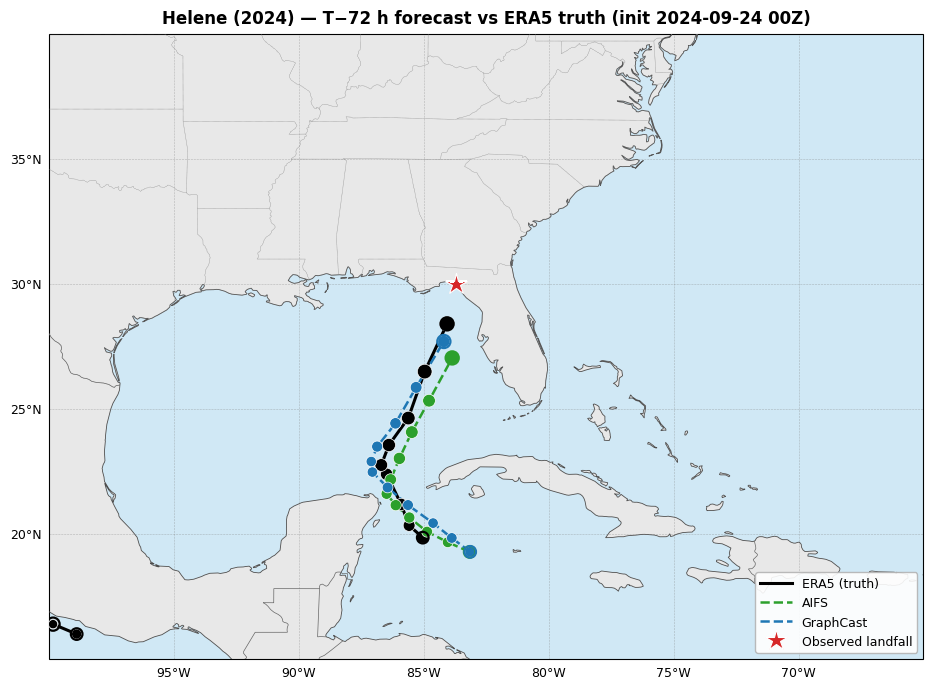

In [24]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_72, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_72, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_72,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−72 h forecast vs ERA5 truth (init {INIT_TIMES[72]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[72],
    nsteps=N_STEPS[72],
    save_path=OUT_DIR / "track_72h.png",
)

In [25]:
df_72 = make_error_table(72, {
    "ERA5 (truth)": era5_tracks_72,
    "AIFS":         aifs_tracks_72,
    "GraphCast":    gc_tracks_72,
})
print(f"\n=== T−72h position error (km) vs ERA5 truth ===\n")
print(df_72.to_string(index=False))


=== T−72h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  09-25 00Z            32                 78
  09-25 06Z            35                 91
  09-25 12Z            23                 94
  09-25 18Z            87                 59
  09-26 00Z            75                 44
  09-26 06Z            73                 48
  09-26 12Z            64                 57
  09-26 18Z           131                 78
  09-27 00Z           153                 79


saved → outputs/helene/track_168h.png


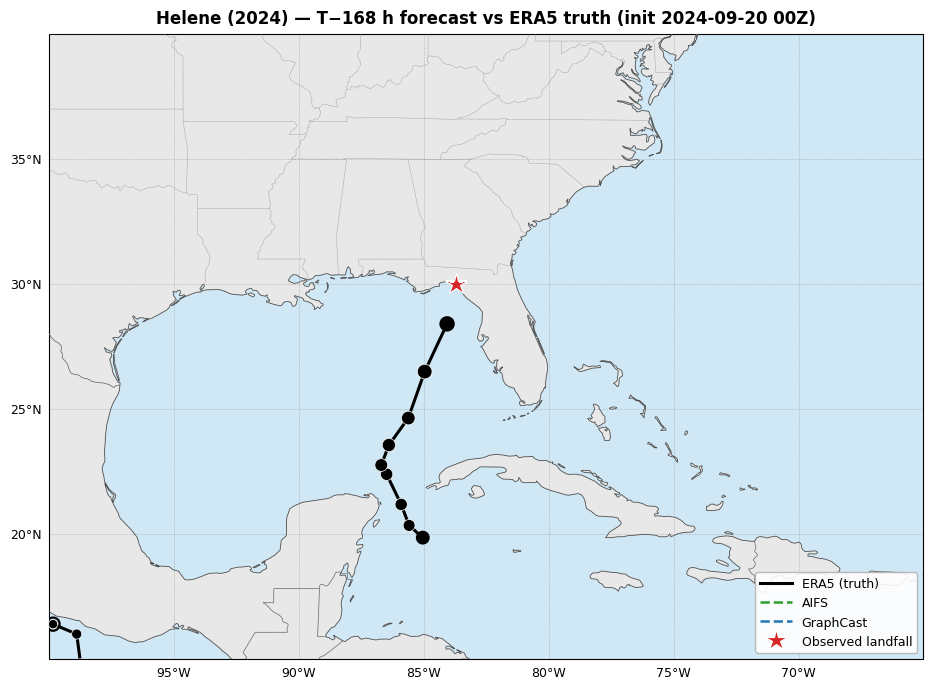

In [26]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_168, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_168, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_168,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−168 h forecast vs ERA5 truth (init {INIT_TIMES[168]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[168],
    nsteps=N_STEPS[168],
    save_path=OUT_DIR / "track_168h.png",
)

In [27]:
df_168 = make_error_table(168, {
    "ERA5 (truth)": era5_tracks_168,
    "AIFS":         aifs_tracks_168,
    "GraphCast":    gc_tracks_168,
})
print(f"\n=== T−168h position error (km) vs ERA5 truth ===\n")
print(df_168.to_string(index=False))


=== T−168h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  09-25 00Z            --                 --
  09-25 06Z            --                 --
  09-25 12Z            --                 --
  09-25 18Z            --                 --
  09-26 00Z            --                 --
  09-26 06Z            --                 --
  09-26 12Z            --                 --
  09-26 18Z            --                 --
  09-27 00Z          4439              12430


saved → outputs/helene/track_240h.png


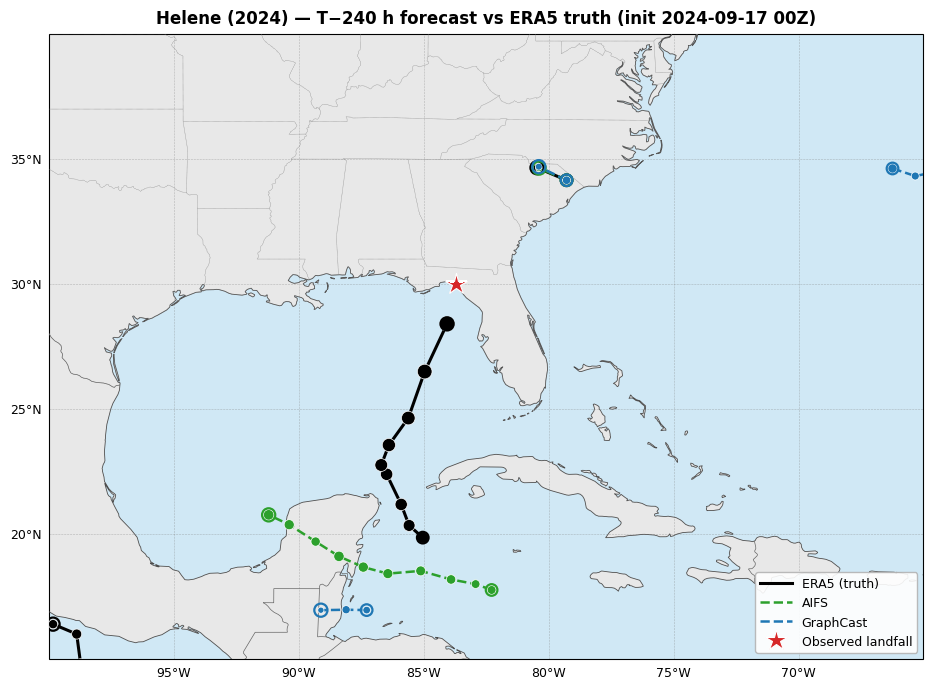

In [28]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_240, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_240, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_240,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−240 h forecast vs ERA5 truth (init {INIT_TIMES[240]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[240],
    nsteps=N_STEPS[240],
    save_path=OUT_DIR / "track_240h.png",
)

In [29]:
df_240 = make_error_table(240, {
    "ERA5 (truth)": era5_tracks_240,
    "AIFS":         aifs_tracks_240,
    "GraphCast":    gc_tracks_240,
})
print(f"\n=== T−240h position error (km) vs ERA5 trumaketh ===\n")
print(df_240.to_string(index=False))


=== T−240h position error (km) vs ERA5 trumaketh ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  09-25 00Z           304               2716
  09-25 06Z           298               2796
  09-25 12Z           307               2862
  09-25 18Z           442               2949
  09-26 00Z           460               3102
  09-26 06Z           537               3182
  09-26 12Z           669               3206
  09-26 18Z           877               3165
  09-27 00Z          1114               3096
